Importación de paquetes necesarios

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import shap 
import joblib

c:\Users\jpela\miniconda3\envs\INATEGA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importación de los dataframes curados con los compuestos y sus respectivos features

In [2]:
df_fisico = pd.read_csv('../data/processed/fisicoquimicos_filtrados.csv')
df_maccs = pd.read_csv('../data/processed/maccs_filtrados.csv')

Separamos las variables independientes (X) y la variable objetivo (y). La columna 'y' (pChEMBL_Value) es exactamente igual en ambos datasets, por lo que con importar una ya será suficiente.

In [3]:
y = df_maccs['pChEMBL_Value'].values
X_fisico = df_fisico.drop(columns=['pChEMBL_Value']).values
X_maccs = df_maccs.drop(columns=['pChEMBL_Value']).values

División Train/Test (80/20). Usamos el mismo random_state=42 para garantizar que las mismas moléculas caigan en Test para ambos modelos

In [4]:
X_train_fisiq, X_test_fisiq, y_train, y_test = train_test_split(X_fisico, y, test_size=0.2, random_state=42)
X_train_mac, X_test_mac, y_train, y_test = train_test_split(X_maccs, y, test_size=0.2, random_state=42)

Definimos y entrenamos los dos modelos Random Forest:

In [5]:
rf_fisico = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_fisico.fit(X_train_fisiq, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [6]:
rf_maccs = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_maccs.fit(X_train_mac, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

Generamos las predicciones en el conjunto de prueba:

In [7]:
y_pred_fisico = rf_fisico.predict(X_test_fisiq)
y_pred_maccs = rf_maccs.predict(X_test_mac)

Evaluamos y comparamos los modelos independientes:

In [8]:
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.497
RMSE:     0.608


In [9]:
print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs)):.3f}")


--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.591
RMSE:     0.548


Estrategia de Consenso: Promediamos las predicciones de ambos modelos

In [10]:
y_pred_consenso = (y_pred_fisico + y_pred_maccs) / 2

print("\n--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso)):.3f}")


--- RENDIMIENTO: MODELO DE CONSENSO (FISICO + MACCS) ---
R2 Score: 0.583
RMSE:     0.553


Let's visualise the true vs the predicted values.

<Axes: xlabel='True', ylabel='Predicted'>

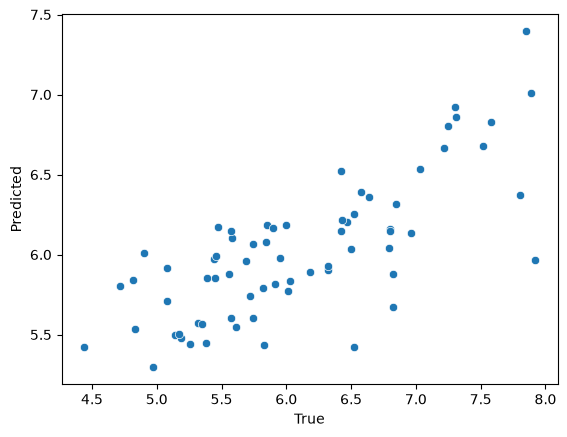

In [11]:
pred_fisico_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_fisico
     }
)
sns.scatterplot(data=pred_fisico_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

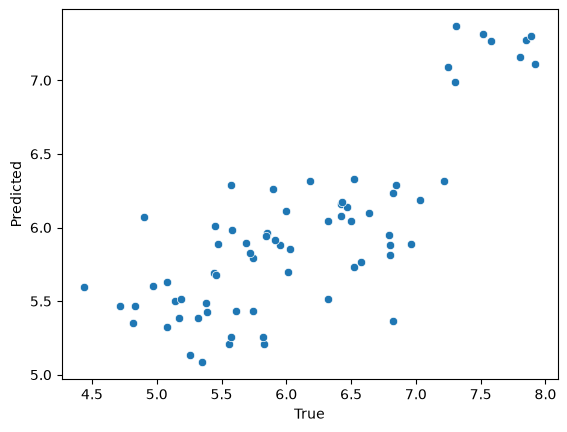

In [12]:
pred_maccs_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_maccs
     }
)
sns.scatterplot(data=pred_maccs_df, x="True", y="Predicted")

<Axes: xlabel='True', ylabel='Predicted'>

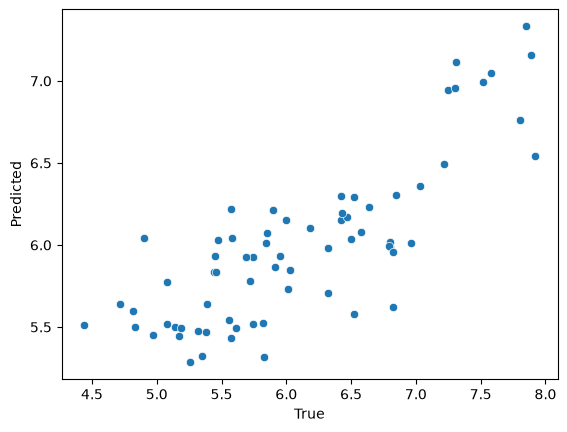

In [13]:
pred_consenso_df = pd.DataFrame(
    {'True': y_test,
     'Predicted': y_pred_consenso
     }
)
sns.scatterplot(data=pred_consenso_df, x="True", y="Predicted")

We are going to use a Random Forest Classifier to classify mitochondiral toxicity. We will
perform a 5 fold grid search cross validation to optimise the parameters of the Classifier.
We can choose between 200 and 300 trees, maximum features to be used in these trees, the
minimum samples to split a node, the maximum depth of a tree.
The taining data will be split into 5 groups and 4 of these will be trained on models varying
these parameters. This will be repeated 5 times and the best performing model's parameters are
stored in the best_estimator

In [14]:
# 1. Definimos la cuadrícula de hiperparámetros a optimizar (param_grid)
param_grid = {
    "n_estimators": [200, 300],              # Evaluamos si necesitas un bosque estándar o más denso
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 5],              # Control básico de ramificación
    "min_samples_leaf": [1, 2],               # Control básico de sobreajuste en las hojas
    "max_depth": [None, 10, 15],              # Puntos clave de profundidad
    'bootstrap': [True]                       # Mantenerlo True suele ser lo mejor en QSAR pequeños
}

In [15]:
# 2. Configuramos el Grid Search con 5-Fold Cross Validation para el modelo Fisicoquímico
print("Optimizando modelo Fisicoquímico (probando combinaciones)...")
grid_fisico = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                           param_grid=param_grid, 
                           cv=5,  
                           n_jobs=-1,  
                           verbose=1) 
grid_fisico.fit(X_train_fisiq, y_train)

Optimizando modelo Fisicoquímico (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [16]:
# 3. Configuramos el Grid Search para el modelo MACCS Keys
print("\nOptimizando modelo MACCS Keys (probando combinaciones)...")
grid_maccs = GridSearchCV(estimator=RandomForestRegressor(random_state=42), 
                          param_grid=param_grid, 
                          cv=5, 
                          n_jobs=-1, 
                          verbose=1)
grid_maccs.fit(X_train_mac, y_train)


Optimizando modelo MACCS Keys (probando combinaciones)...
Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_mo

In [17]:
# 4. Extraemos los mejores hiperparámetros encontrados para cada modelo
print("\nMejores hiperparámetros Fisicoquímicos:", grid_fisico.best_params_)
print("Mejores hiperparámetros MACCS:", grid_maccs.best_params_)


Mejores hiperparámetros Fisicoquímicos: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Mejores hiperparámetros MACCS: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


In [18]:
# 5. Extraemos los modelos ya optimizados automáticamente por Grid Search
best_rf_fisico = grid_fisico.best_estimator_
best_rf_maccs = grid_maccs.best_estimator_

In [19]:
# 6. Generamos las nuevas predicciones optimizadas aplicándolas a los datos de Prueba (Test)
y_pred_fisico_opt = best_rf_fisico.predict(X_test_fisiq)
y_pred_maccs_opt = best_rf_maccs.predict(X_test_mac)

In [20]:
# 7. Calculamos el nuevo Consenso (promedio de las predicciones de los mejores modelos)
y_pred_consenso_opt = (y_pred_fisico_opt + y_pred_maccs_opt) / 2

In [21]:
# 8. Evaluamos el Consenso Final de los modelos Optimizados
print("\n--- RENDIMIENTO: MODELO FISICOQUÍMICO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_fisico_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_fisico_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO MACCS KEYS ---")
print(f"R2 Score: {r2_score(y_test, y_pred_maccs_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_maccs_opt)):.3f}")

print("\n--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---")
print(f"R2 Score: {r2_score(y_test, y_pred_consenso_opt):.3f}")
print(f"RMSE:     {np.sqrt(mean_squared_error(y_test, y_pred_consenso_opt)):.3f}")


--- RENDIMIENTO: MODELO FISICOQUÍMICO ---
R2 Score: 0.486
RMSE:     0.614

--- RENDIMIENTO: MODELO MACCS KEYS ---
R2 Score: 0.567
RMSE:     0.564

--- RENDIMIENTO: MODELO CONSENSO OPTIMIZADO ---
R2 Score: 0.552
RMSE:     0.573


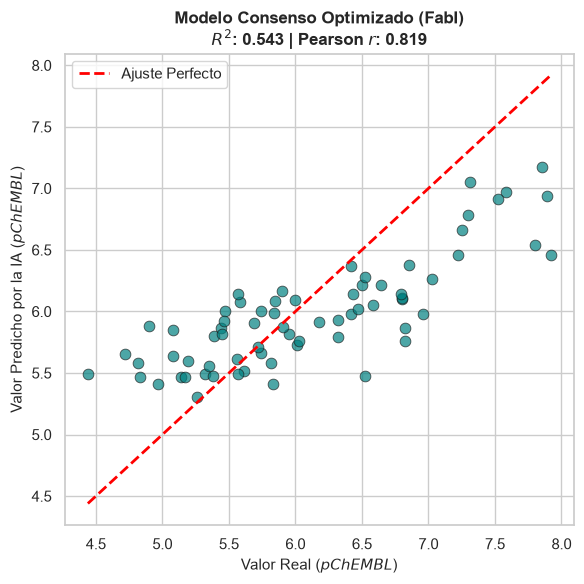

In [22]:
# 1. Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Dibujamos los puntos (Real vs Predicho del Consenso)
sns.scatterplot(x=y_test, y=y_pred_consenso_opt, alpha=0.7, color='teal', edgecolor='k', s=60)

# 3. Dibujamos la línea de ajuste perfecto (diagonal)
p1 = max(max(y_test), max(y_pred_consenso_opt))
p2 = min(min(y_test), min(y_pred_consenso_opt))
plt.plot([p2, p1], [p2, p1], color='red', linestyle='--', linewidth=2, label="Ajuste Perfecto")

# 4. Calculamos la correlación de Pearson para la gráfica
r_val, _ = pearsonr(y_test, y_pred_consenso_opt)

# 5. Títulos y etiquetas (Aseguramos que muestre tu R² real de 0.543)
plt.title(f"Modelo Consenso Optimizado (FabI)\n$R^2$: {0.543:.3f} | Pearson $r$: {r_val:.3f}", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real ($pChEMBL$)", fontsize=11)
plt.ylabel("Valor Predicho por la IA ($pChEMBL$)", fontsize=11)
plt.legend(loc="upper left")

# 6. Ajustamos márgenes y guardamos
plt.tight_layout()
plt.savefig("../results/correlacion_consenso_qsar.png", dpi=300)
plt.show()

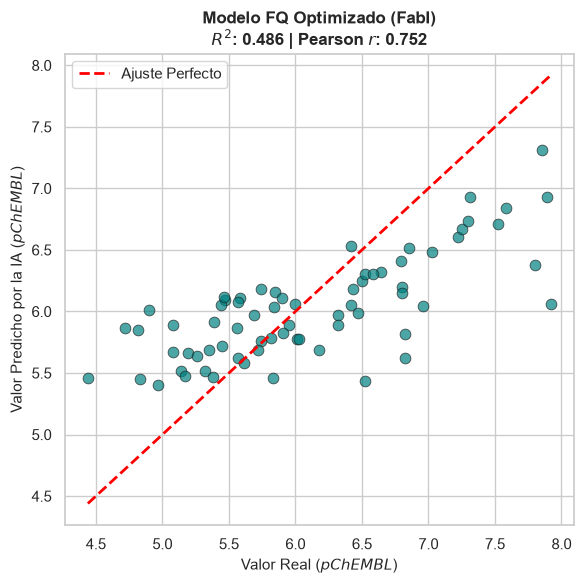

In [33]:
# 1. Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Dibujamos los puntos (Real vs Predicho del Consenso)
sns.scatterplot(x=y_test, y=y_pred_fisico_opt, alpha=0.7, color='teal', edgecolor='k', s=60)

# 3. Dibujamos la línea de ajuste perfecto (diagonal)
p1 = max(max(y_test), max(y_pred_fisico_opt))
p2 = min(min(y_test), min(y_pred_fisico_opt))
plt.plot([p2, p1], [p2, p1], color='red', linestyle='--', linewidth=2, label="Ajuste Perfecto")

# 4. Calculamos la correlación de Pearson para la gráfica
r_val, _ = pearsonr(y_test, y_pred_fisico_opt)

# 5. Títulos y etiquetas (Aseguramos que muestre tu R² real de 0.543)
plt.title(f"Modelo FQ Optimizado (FabI)\n$R^2$: {0.486:.3f} | Pearson $r$: {r_val:.3f}", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real ($pChEMBL$)", fontsize=11)
plt.ylabel("Valor Predicho por la IA ($pChEMBL$)", fontsize=11)
plt.legend(loc="upper left")

# 6. Ajustamos márgenes y guardamos
plt.tight_layout()
plt.savefig("../results/correlacion_fisico_qsar.png", dpi=300)
plt.show()

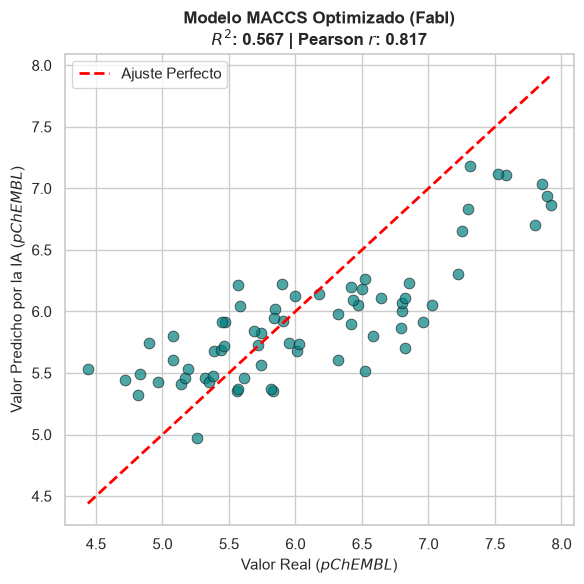

In [34]:
# 1. Configuramos el estilo de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, 6))

# 2. Dibujamos los puntos (Real vs Predicho del Consenso)
sns.scatterplot(x=y_test, y=y_pred_maccs_opt, alpha=0.7, color='teal', edgecolor='k', s=60)

# 3. Dibujamos la línea de ajuste perfecto (diagonal)
p1 = max(max(y_test), max(y_pred_maccs_opt))
p2 = min(min(y_test), min(y_pred_maccs_opt))
plt.plot([p2, p1], [p2, p1], color='red', linestyle='--', linewidth=2, label="Ajuste Perfecto")

# 4. Calculamos la correlación de Pearson para la gráfica
r_val, _ = pearsonr(y_test, y_pred_maccs_opt)

# 5. Títulos y etiquetas (Aseguramos que muestre tu R² real de 0.543)
plt.title(f"Modelo MACCS Optimizado (FabI)\n$R^2$: {0.567:.3f} | Pearson $r$: {r_val:.3f}", fontsize=12, fontweight='bold')
plt.xlabel("Valor Real ($pChEMBL$)", fontsize=11)
plt.ylabel("Valor Predicho por la IA ($pChEMBL$)", fontsize=11)
plt.legend(loc="upper left")

# 6. Ajustamos márgenes y guardamos
plt.tight_layout()
plt.savefig("../results/correlacion_maccs_qsar.png", dpi=300)
plt.show()

Interpretación de los resultados de predicción del modelo: Sabemos cómo predice el modelo, pero no por qué se llega a un resultado u otro, ni qué descriptores han tenido más peso en el valor de ChEBML predicho. Para poder interpretar los resultados del modelo utilizaremos
SHAP, una herramienta que permite conocer cuánto contribuye cada descriptor a la predicción final.

Empezaremos con el modelo de deescriptores fisico-químicos.

In [23]:
# 1. Recuperamos los nombres de las columnas (quitando la variable objetivo si estuviera)
nombres_columnas = list(df_fisico.columns)
if 'pChEMBL_Value' in nombres_columnas: nombres_columnas.remove('pChEMBL_Value')

In [24]:
# 2. Forzamos que tu X_test vuelva a ser un DataFrame con sus nombres oficiales
X_test_fisiq_df = pd.DataFrame(X_test_fisiq, columns=nombres_columnas)

In [25]:
# 3. 
explainer = shap.Explainer(best_rf_fisico, X_test_fisiq_df)
shap_values_fisiq = explainer(X_test_fisiq_df)

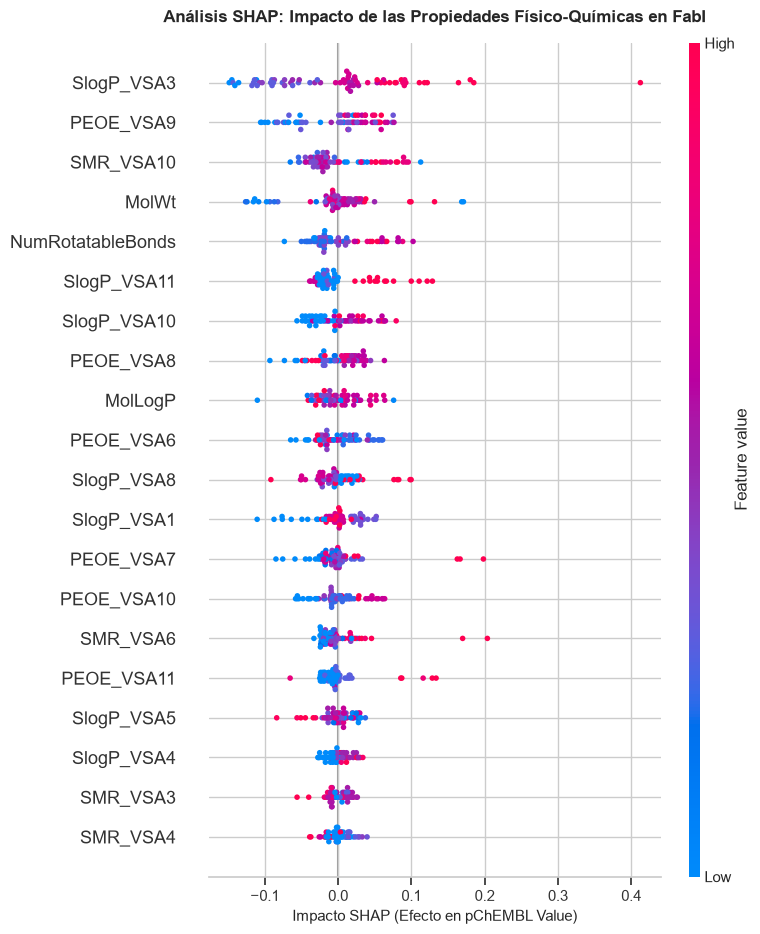

In [26]:
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values_fisiq, 
    X_test_fisiq, 
    max_display=20,    # Mostramos los 15 descriptores físico-químicos más influyentes
    plot_type="dot",   # Forzamos nubes de puntos (azules/rojos)
    feature_names=nombres_columnas,
    show=False
)
# Ajustes estéticos finales
plt.title("Análisis SHAP: Impacto de las Propiedades Físico-Químicas en FabI", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Impacto SHAP (Efecto en pChEMBL Value)", fontsize=11)
plt.tight_layout()
# Guardamos la gráfica limpia para tu documento
plt.savefig("../results/shap_summary_fisicoquimicos.png", dpi=300)
plt.show()

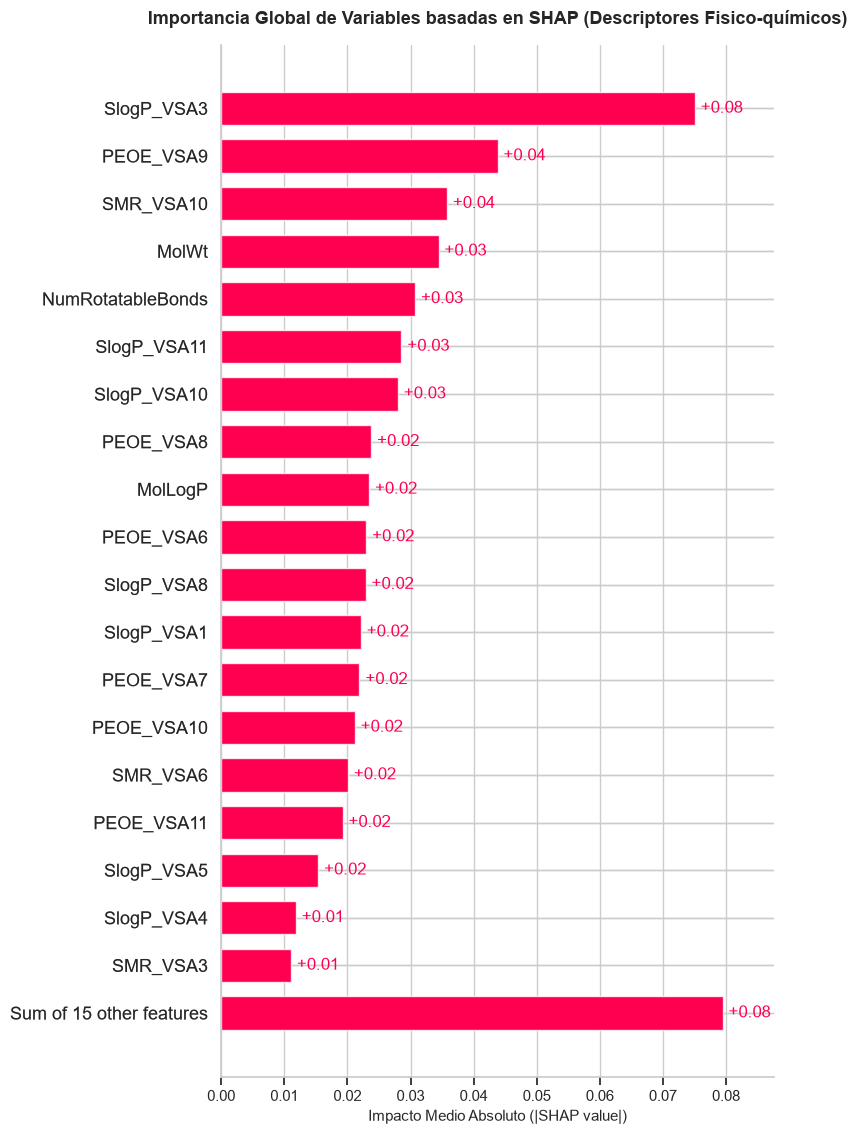

In [27]:
# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 8))

# Invocamos el gráfico de barras nativo de SHAP
# (.plots.bar calcula de forma automática el valor medio absoluto)
shap.plots.bar(shap_values_fisiq, max_display=20, show=False)

# Ajustes estéticos finales
plt.title("Importancia Global de Variables basadas en SHAP (Descriptores Fisico-químicos)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Impacto Medio Absoluto (|SHAP value|)", fontsize=11)
plt.tight_layout()

# Guardamos la imagen
plt.savefig("../results/shap_barplot_nativo_fisico.png", dpi=300)
plt.show()

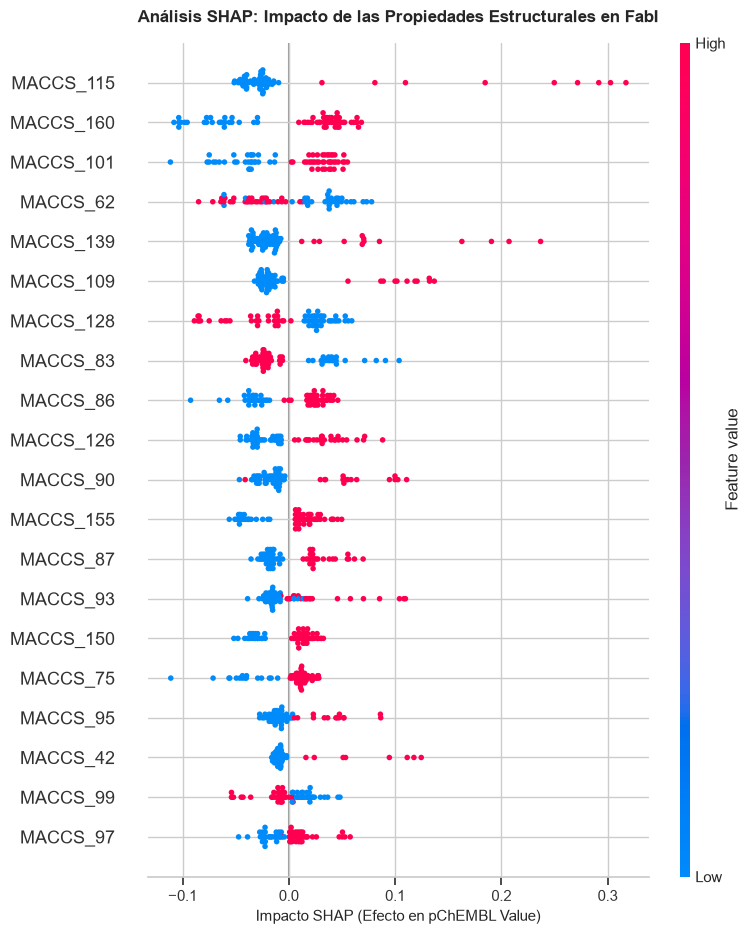

In [28]:
# Repetimos lo mismo con el otro modelo
nombres_maccs = [col for col in df_maccs.columns if col not in ['Smiles', 'pChEMBL_Value', 'pChEMBL Value']]
X_test_mac_df = pd.DataFrame(X_test_mac, columns=nombres_maccs)
explainer = shap.Explainer(best_rf_maccs, X_test_mac)
shap_values_mac = explainer(X_test_mac_df)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_mac, 
    X_test_mac, 
    max_display=20,    # Mostramos los 15 descriptores físico-químicos más influyentes
    plot_type="dot",   # Forzamos nubes de puntos (azules/rojos)
    show=False
)
# Ajustes estéticos finales
plt.title("Análisis SHAP: Impacto de las Propiedades Estructurales en FabI", fontsize=12, fontweight='bold', pad=15)
plt.xlabel("Impacto SHAP (Efecto en pChEMBL Value)", fontsize=11)
plt.tight_layout()
# Guardamos la gráfica limpia para tu documento
plt.savefig("../results/shap_summary_maccs.png", dpi=300)
plt.show()

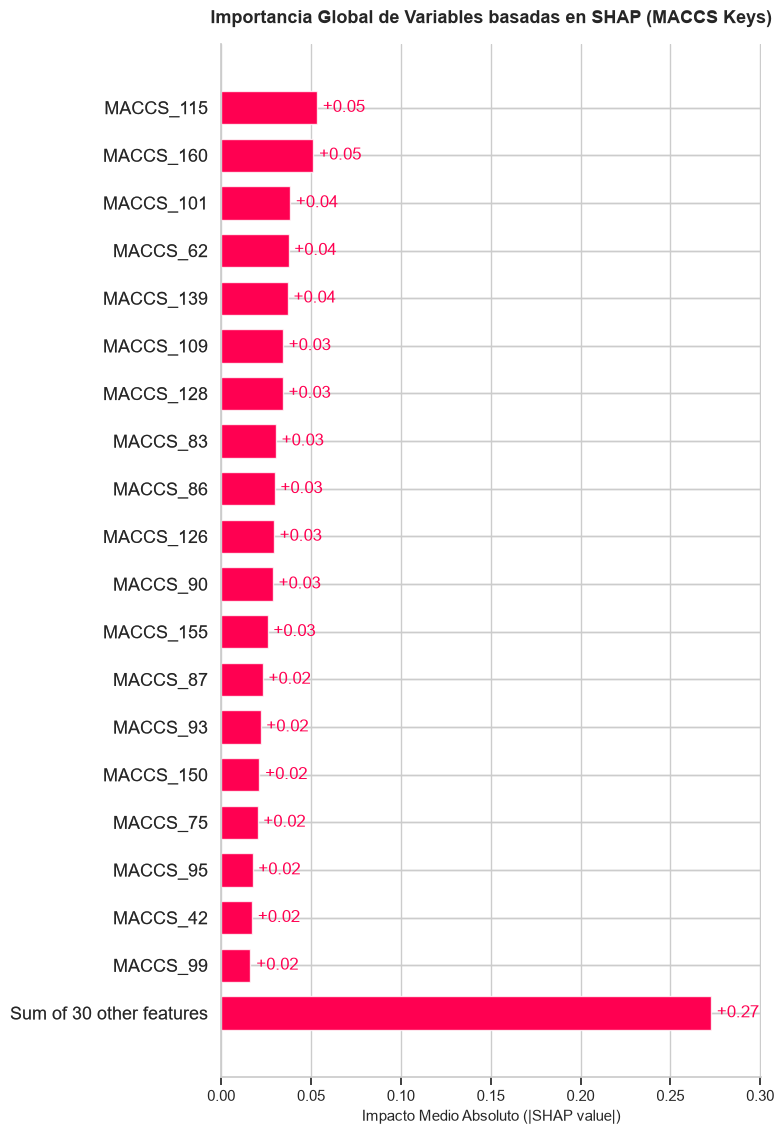

In [29]:
# Configuramos el tamaño de la figura
plt.figure(figsize=(10, 8))

# Invocamos el gráfico de barras nativo de SHAP
# (.plots.bar calcula de forma automática el valor medio absoluto)
shap.plots.bar(shap_values_mac, max_display=20, show=False)

# Ajustes estéticos finales
plt.title("Importancia Global de Variables basadas en SHAP (MACCS Keys)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Impacto Medio Absoluto (|SHAP value|)", fontsize=11)
plt.tight_layout()

# Guardamos la imagen
plt.savefig("../results/shap_barplot_nativo_maccs.png", dpi=300)
plt.show()

In [30]:
# Exportamos ambos modelos optimizados a archivos .pkl en tu ordenador
joblib.dump(best_rf_fisico, '../results/models/mejor_modelo_fisicoquimico.pkl')
joblib.dump(best_rf_maccs, '../results/models/mejor_modelo_maccs.pkl')

print("¡Modelos exportados y guardados en el disco con éxito!")

¡Modelos exportados y guardados en el disco con éxito!
